# SMS Spam Collection - Data Exploration

This notebook shows, step by step, exactly how every number in the proposal (total messages, class balance, duplicates, message length) was produced - so each result can be reproduced and explained, not just quoted.

**Data file:** `data/spam.csv` - the Kaggle mirror of the UCI SMS Spam Collection (columns `v1`=label, `v2`=message, plus 3 empty `Unnamed` columns from the original Excel export).

## 1. Load the raw file
The file needs `encoding='latin-1'` - it isn't plain UTF-8, and reading it as UTF-8 raises an error.

In [2]:
import pandas as pd

raw = pd.read_csv('../data/spam.csv', encoding='latin-1')
print('Raw shape:', raw.shape)
raw.head(3)

Raw shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


## 2. Clean up the columns
Only `v1` (label) and `v2` (message) hold real data - the other 3 columns are empty artifacts of how the file was exported from Excel. Drop them and rename the two real columns.

In [3]:
df = raw[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df.head(3)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


## 3. Total messages
Simply the number of rows once the junk columns are gone.

In [4]:
total_messages = len(df)
print(f'Total messages: {total_messages:,}')

Total messages: 5,572


## 4. Class balance (ham vs spam)
Count how many rows have each label, then turn those counts into percentages.

In [5]:
counts = df['label'].value_counts()
pct = (counts / total_messages * 100).round(1)

for label in counts.index:
    print(f'{label:5s}: {counts[label]:,} messages ({pct[label]}%)')

ham  : 4,825 messages (86.6%)
spam : 747 messages (13.4%)


## 5. Duplicate messages
`nunique()` counts *distinct* message texts. If that number is smaller than the total, some messages appear more than once in the file.

In [6]:
unique_messages = df['message'].nunique()
duplicates = total_messages - unique_messages

print(f'Total messages:   {total_messages:,}')
print(f'Unique messages:  {unique_messages:,}')
print(f'Duplicates:       {duplicates:,}')

Total messages:   5,572
Unique messages:  5,169
Duplicates:       403


## 6. Remove duplicates before analyzing further
Keep only the first occurrence of each message, so a repeated message can't be counted twice (e.g. split into both train and test later).

In [7]:
df_dedup = df.drop_duplicates(subset='message', keep='first').reset_index(drop=True)
print('Rows before:', len(df))
print('Rows after: ', len(df_dedup))

Rows before: 5572
Rows after:  5169


## 7. Message length by class (word count)
For each message, count words with `.split()`. Then group by label and compute the mean and median.

In [8]:
df_dedup['word_count'] = df_dedup['message'].str.split().str.len()

length_stats = df_dedup.groupby('label')['word_count'].agg(['mean', 'median']).round(1)
length_stats

,mean,median
label,,
ham,14.1,11.0
spam,23.7,25.0


## 8. Put it all together
The same numbers, collected in one place — this is what ended up in the proposal's dataset table.

In [10]:
summary = {
    'total_messages': total_messages,
    'ham_count': int(counts['ham']),
    'spam_count': int(counts['spam']),
    'spam_pct': float(pct['spam']),
    'unique_messages': unique_messages,
    'duplicate_messages': duplicates,
    'ham_len_mean': float(length_stats.loc['ham', 'mean']),
    'spam_len_mean': float(length_stats.loc['spam', 'mean']),
}
summary

{'total_messages': 5572,
 'ham_count': 4825,
 'spam_count': 747,
 'spam_pct': 13.4,
 'unique_messages': 5169,
 'duplicate_messages': 403,
 'ham_len_mean': 14.1,
 'spam_len_mean': 23.7}

## 9. Two quick plots
Class balance (bar) and message length by class (histogram)


In [11]:
# Table 1 — representative samples (4 ham, 4 spam)
sample = df_dedup.groupby('label').sample(n=4, random_state=42)
sample

,label,message,word_count
1819,ham,"Come to me, slave. Your doing it again ... Goi...",24
1654,ham,U meet other fren dun wan meet me ah... Muz b ...,14
4586,ham,"G says you never answer your texts, confirm/deny",8
1260,ham,"K so am I, how much for an 8th? Fifty?",10
3799,spam,Win a å£1000 cash prize or a prize worth å£5000,10
4771,spam,PRIVATE! Your 2003 Account Statement for 078,7
2511,spam,"FREE RING TONE just text \POLYS\"" to 87131. Th...",18
1721,spam,BIG BROTHER ALERT! The computer has selected u...,27


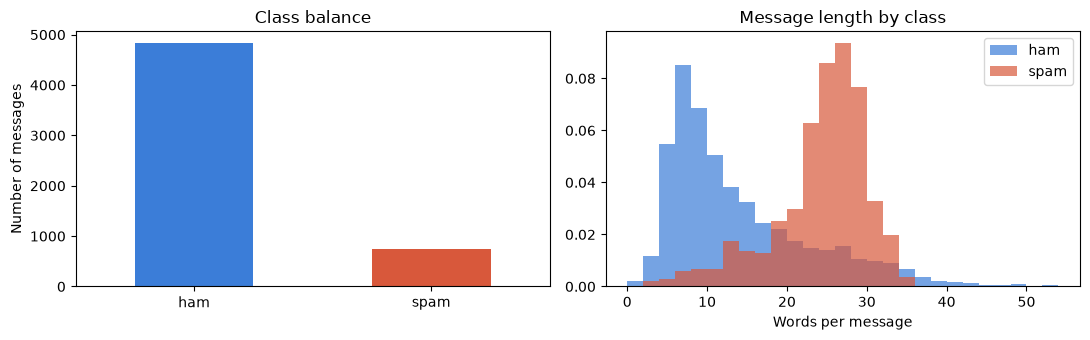

In [12]:
import matplotlib.pyplot as plt

HAM, SPAM = '#3B7DD8', '#D8583B'

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

counts.plot(kind='bar', color=[HAM, SPAM], ax=axes[0])
axes[0].set_title('Class balance')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of messages')
axes[0].tick_params(axis='x', rotation=0)

for label, color in [('ham', HAM), ('spam', SPAM)]:
    vals = df_dedup.loc[df_dedup['label'] == label, 'word_count']
    axes[1].hist(vals, bins=range(0, 55, 2), alpha=0.7, label=label, color=color, density=True)
axes[1].set_title('Message length by class')
axes[1].set_xlabel('Words per message')
axes[1].legend()

fig.tight_layout()
plt.show()